In [2]:
# ============================================================
# Housing Affordability DSS — Notebook 01: EDA
# CS7P01: MSc Project | London Metropolitan University
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# ── Plot styling ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.figsize':    (13, 6),
    'axes.titlesize':    14,
    'axes.labelsize':    12,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'serif',
    'axes.titlepad':     14
})

PALETTE = [
    '#1F3864', '#2E5090', '#C0392B', '#27AE60', '#E67E22',
    '#8E44AD', '#2980B9', '#D35400', '#16A085', '#2C3E50'
]

# ── Paths ─────────────────────────────────────────────────────
RAW       = '../data/raw/'
PROCESSED = '../data/processed/'
os.makedirs(PROCESSED, exist_ok=True)

# ── Verified region list (exact strings from source file) ───────
REGIONS = [
    'East Midlands',
    'East of England',
    'London',
    'North East',
    'North West',
    'South East',
    'South West',
    'West Midlands Region',   # NOTE: NOT 'West Midlands' — that is the LA
    'Yorkshire and The Humber',
    'Wales'
]

print("✓ Environment ready")
print(f"  Regions defined : {len(REGIONS)}")
print(f"  Raw path        : {os.path.abspath(RAW)}")
print(f"  Processed path  : {os.path.abspath(PROCESSED)}")

✓ Environment ready
  Regions defined : 10
  Raw path        : /Users/sushansunuwar/LondonMet/housing-dss/data/raw
  Processed path  : /Users/sushansunuwar/LondonMet/housing-dss/data/processed


In [3]:
# ============================================================
# DATASET 1: Land Registry UK HPI Full File 2025
# Monthly house price data by region and local authority
# Source: https://www.gov.uk/government/collections/uk-house-price-index
#
# Columns used:
#   Date            — monthly date of record
#   RegionName      — geography (we filter to 10 regions)
#   AveragePrice    — mix-adjusted mean price, all properties
#   AveragePriceSA  — seasonally adjusted average price
#   SalesVolume     — number of transactions (proxy for market activity)
#   12m%Change      — year-on-year % price change (pre-computed)
#   IndexSA         — seasonally adjusted index (base Jan 2015 = 100)
# ============================================================

hpi_raw = pd.read_csv(
    RAW + 'land_registry_hpi_full_2025.csv',
    encoding='utf-8'
)

print(f"── Raw HPI shape : {hpi_raw.shape}")
print(f"── Columns       : {hpi_raw.columns.tolist()}")

── Raw HPI shape : (149085, 54)
── Columns       : ['Date', 'RegionName', 'AreaCode', 'AveragePrice', 'Index', 'IndexSA', '1m%Change', '12m%Change', 'AveragePriceSA', 'SalesVolume', 'DetachedPrice', 'DetachedIndex', 'Detached1m%Change', 'Detached12m%Change', 'SemiDetachedPrice', 'SemiDetachedIndex', 'SemiDetached1m%Change', 'SemiDetached12m%Change', 'TerracedPrice', 'TerracedIndex', 'Terraced1m%Change', 'Terraced12m%Change', 'FlatPrice', 'FlatIndex', 'Flat1m%Change', 'Flat12m%Change', 'CashPrice', 'CashIndex', 'Cash1m%Change', 'Cash12m%Change', 'CashSalesVolume', 'MortgagePrice', 'MortgageIndex', 'Mortgage1m%Change', 'Mortgage12m%Change', 'MortgageSalesVolume', 'FTBPrice', 'FTBIndex', 'FTB1m%Change', 'FTB12m%Change', 'FOOPrice', 'FOOIndex', 'FOO1m%Change', 'FOO12m%Change', 'NewPrice', 'NewIndex', 'New1m%Change', 'New12m%Change', 'NewSalesVolume', 'OldPrice', 'OldIndex', 'Old1m%Change', 'Old12m%Change', 'OldSalesVolume']


In [4]:
# ── Filter to our 10 regions only ────────────────────────────
hpi = hpi_raw[hpi_raw['RegionName'].isin(REGIONS)].copy()

# ── Parse date ───────────────────────────────────────────────
# Format is DD/MM/YYYY — must use dayfirst=True
hpi['Date'] = pd.to_datetime(hpi['Date'], dayfirst=True)
hpi['Year']  = hpi['Date'].dt.year
hpi['Month'] = hpi['Date'].dt.month

# ── Select and rename columns we will use ────────────────────
hpi = hpi[[
    'Date', 'Year', 'Month', 'RegionName',
    'AveragePrice', 'AveragePriceSA',
    'SalesVolume', '12m%Change', 'IndexSA'
]].copy()

hpi.columns = [
    'date', 'year', 'month', 'region',
    'avg_price', 'avg_price_sa',
    'sales_volume', 'yoy_pct_change', 'index_sa'
]

# ── Convert numeric columns — some may have come in as strings
for col in ['avg_price', 'avg_price_sa', 'sales_volume',
            'yoy_pct_change', 'index_sa']:
    hpi[col] = pd.to_numeric(hpi[col], errors='coerce')

# ── Sort ──────────────────────────────────────────────────────
hpi = hpi.sort_values(['region', 'date']).reset_index(drop=True)

# ── Verification ──────────────────────────────────────────────
print(f"\n── Filtered HPI shape : {hpi.shape}")
print(f"── Regions found      : {sorted(hpi['region'].unique())}")
print(f"── Date range         : {hpi['date'].min()} → {hpi['date'].max()}")
print(f"\n── Missing values:\n{hpi.isnull().sum()}")
hpi.head(10)


── Filtered HPI shape : (5745, 9)
── Regions found      : ['East Midlands', 'East of England', 'London', 'North East', 'North West', 'South East', 'South West', 'Wales', 'West Midlands Region', 'Yorkshire and The Humber']
── Date range         : 1968-04-01 00:00:00 → 2025-12-01 00:00:00

── Missing values:
date                 0
year                 0
month                0
region               0
avg_price            0
avg_price_sa      2025
sales_volume      2045
yoy_pct_change     120
index_sa          2025
dtype: int64


,date,year,month,region,avg_price,avg_price_sa,sales_volume,yoy_pct_change,index_sa
0,1968-04-01,1968,4,East Midlands,2914,NaN,NaN,NaN,NaN
1,1968-05-01,1968,5,East Midlands,2914,NaN,NaN,NaN,NaN
2,1968-06-01,1968,6,East Midlands,2914,NaN,NaN,NaN,NaN
3,1968-07-01,1968,7,East Midlands,3057,NaN,NaN,NaN,NaN
4,1968-08-01,1968,8,East Midlands,3057,NaN,NaN,NaN,NaN
5,1968-09-01,1968,9,East Midlands,3057,NaN,NaN,NaN,NaN
6,1968-10-01,1968,10,East Midlands,2961,NaN,NaN,NaN,NaN
7,1968-11-01,1968,11,East Midlands,2961,NaN,NaN,NaN,NaN
8,1968-12-01,1968,12,East Midlands,2961,NaN,NaN,NaN,NaN
9,1969-01-01,1969,1,East Midlands,2995,NaN,NaN,NaN,NaN


In [5]:
# ============================================================
# SANITY CHECK — Verify each region has the expected row count
# Monthly data from ~1995 to 2025 = ~360 rows per region
# Flag any region with significantly fewer rows
# ============================================================

region_counts = hpi.groupby('region').size().reset_index(name='row_count')
region_counts['date_start'] = hpi.groupby('region')['date'].min().values
region_counts['date_end']   = hpi.groupby('region')['date'].max().values

print("── Rows per region:")
print(region_counts.to_string(index=False))

# Check for any region with unexpected gaps
expected_months = (hpi['date'].max().year - hpi['date'].min().year) * 12
print(f"\n── Expected months per region (approx): {expected_months}")
print(f"── Any regions with gaps? "
      f"{region_counts[region_counts['row_count'] < expected_months * 0.95]['region'].tolist()}")

── Rows per region:
                  region  row_count date_start   date_end
           East Midlands        693 1968-04-01 2025-12-01
         East of England        405 1992-04-01 2025-12-01
                  London        693 1968-04-01 2025-12-01
              North East        405 1992-04-01 2025-12-01
              North West        372 1995-01-01 2025-12-01
              South East        405 1992-04-01 2025-12-01
              South West        693 1968-04-01 2025-12-01
                   Wales        693 1968-04-01 2025-12-01
    West Midlands Region        693 1968-04-01 2025-12-01
Yorkshire and The Humber        693 1968-04-01 2025-12-01

── Expected months per region (approx): 684
── Any regions with gaps? ['East of England', 'North East', 'North West', 'South East']


In [6]:
# ============================================================
# CELL 4 — Apply Date Filter: 1995 onwards
#
# Rationale: ONS affordability ratio series begins in 1997.
# We use 1995 as our start to retain 2 years of price data
# before the ratio series begins — useful for context plots
# and lag features in modelling.
# Pre-1995 data has no matching earnings/ratio data and
# contains no seasonally adjusted values — not useful.
# ============================================================

hpi = hpi[hpi['year'] >= 1995].copy().reset_index(drop=True)

# ── Re-check after filter ─────────────────────────────────────
print(f"── Filtered shape (1995+) : {hpi.shape}")
print(f"── Date range             : {hpi['date'].min()} → {hpi['date'].max()}")
print(f"\n── Missing values after filter:")
print(hpi.isnull().sum())

print(f"\n── Rows per region after filter:")
print(hpi.groupby('region').agg(
    rows       = ('date', 'count'),
    date_start = ('date', 'min'),
    date_end   = ('date', 'max')
).to_string())

── Filtered shape (1995+) : (3720, 9)
── Date range             : 1995-01-01 00:00:00 → 2025-12-01 00:00:00

── Missing values after filter:
date               0
year               0
month              0
region             0
avg_price          0
avg_price_sa       0
sales_volume      20
yoy_pct_change    12
index_sa           0
dtype: int64

── Rows per region after filter:
                          rows date_start   date_end
region                                              
East Midlands              372 1995-01-01 2025-12-01
East of England            372 1995-01-01 2025-12-01
London                     372 1995-01-01 2025-12-01
North East                 372 1995-01-01 2025-12-01
North West                 372 1995-01-01 2025-12-01
South East                 372 1995-01-01 2025-12-01
South West                 372 1995-01-01 2025-12-01
Wales                      372 1995-01-01 2025-12-01
West Midlands Region       372 1995-01-01 2025-12-01
Yorkshire and The Humber   372 1995-01-0

In [7]:
# Save cleaned HPI to processed folder
hpi.to_csv(PROCESSED + 'hpi_clean.csv', index=False)
print("✓ hpi_clean.csv saved")

✓ hpi_clean.csv saved


In [8]:
# ============================================================
# CELL 5 — Load ONS HP Earnings Ratio: Sheet 1c
# Median affordability ratio by country and region 1997–2025
# This is your PRIMARY affordability series — the main
# target variable for all modelling and forecasting.
#
# File structure (verified from screenshot):
#   Row 1  = title (skip)
#   Row 2  = headers: Code, Name, 1997, 1998 ... 2025
#   Row 3+ = data in wide format (regions as rows, years as cols)
# ============================================================

ratio_raw = pd.read_excel(
    RAW + 'ons_hp_earnings_ratio.xlsx',
    sheet_name='1c',
    header=1        # Row 2 is the header (0-indexed = 1)
)

print(f"── Raw shape        : {ratio_raw.shape}")
print(f"── Columns          : {ratio_raw.columns.tolist()}")
print(f"\n── First 5 rows:")
ratio_raw.head()

── Raw shape        : (12, 32)
── Columns          : ['Code', 'Name', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '5-Year Average']

── First 5 rows:


,Code,Name,1997,1998,1999,2000,2001,2002,2003,2004,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,5-Year Average
0,K04000001,England and Wales,3.55,3.66,3.89,4.13,4.42,5.06,5.85,6.53,...,7.77,7.85,7.73,7.82,8.95,8.45,8.28,7.74,7.55,8.19
1,E92000001,England,3.54,3.67,3.96,4.19,4.50,5.12,5.93,6.60,...,7.91,8.04,7.88,7.86,9.06,8.56,8.45,7.84,7.63,8.31
2,W92000004,Wales,3.00,3.04,3.16,3.26,3.33,3.71,4.31,5.43,...,5.76,5.92,5.83,5.88,6.57,6.43,6.24,6.13,5.95,6.26
3,E12000001,North East,2.98,3.01,3.07,2.98,3.02,3.29,3.95,4.78,...,5.21,5.31,5.21,5.21,5.81,5.25,5.34,5.07,5.00,5.29
4,E12000002,North West,3.01,3.01,3.09,3.13,3.23,3.51,4.02,4.87,...,5.79,5.84,5.86,5.91,6.78,6.52,6.35,6.11,5.92,6.34


In [9]:
# ============================================================
# CELL 6 — Clean and reshape ratio data
#
# Current shape: wide — each year is a column
# Target shape:  long — one row per region per year
#
# Regions in this file use 'West Midlands' (not 'West Midlands
# Region' as in HPI) — we standardise naming here.
# ============================================================

# ── Define region mapping ─────────────────────────────────────
# Maps ONS sheet names → our standard REGIONS list
# Only keep the 10 regions we are modelling
RATIO_REGION_MAP = {
    'England and Wales':          'England and Wales',  # national benchmark
    'England':                    'England',            # national benchmark
    'Wales':                      'Wales',
    'North East':                 'North East',
    'North West':                 'North West',
    'Yorkshire and The Humber':   'Yorkshire and The Humber',
    'East Midlands':              'East Midlands',
    'West Midlands':              'West Midlands Region',  # standardise name
    'East of England':            'East of England',
    'London':                     'London',
    'South East':                 'South East',
    'South West':                 'South West',
}

# ── Filter to our regions ─────────────────────────────────────
ratio_filtered = ratio_raw[
    ratio_raw['Name'].isin(RATIO_REGION_MAP.keys())
].copy()

# ── Identify year columns ─────────────────────────────────────
year_cols = [c for c in ratio_filtered.columns
             if str(c).strip().isdigit() and 1997 <= int(str(c).strip()) <= 2025]

print(f"── Year columns found : {year_cols}")
print(f"── Regions before melt: {ratio_filtered['Name'].tolist()}")

# ── Melt wide → long ──────────────────────────────────────────
ratio_long = ratio_filtered.melt(
    id_vars=['Code', 'Name'],
    value_vars=year_cols,
    var_name='year',
    value_name='affordability_ratio'
)

# ── Clean up ──────────────────────────────────────────────────
ratio_long['year'] = pd.to_numeric(ratio_long['year'], errors='coerce').astype('Int64')
ratio_long['affordability_ratio'] = pd.to_numeric(ratio_long['affordability_ratio'], errors='coerce')

# Standardise region names to match HPI file
ratio_long['region'] = ratio_long['Name'].map(RATIO_REGION_MAP)

# Drop Code and Name — replaced by standardised region
ratio_long = ratio_long.drop(columns=['Code', 'Name'])
ratio_long = ratio_long.dropna(subset=['affordability_ratio'])
ratio_long = ratio_long.sort_values(['region', 'year']).reset_index(drop=True)

print(f"\n── Long format shape  : {ratio_long.shape}")
print(f"── Regions            : {sorted(ratio_long['region'].unique())}")
print(f"── Year range         : {ratio_long['year'].min()} → {ratio_long['year'].max()}")
print(f"\n── Missing values:\n{ratio_long.isnull().sum()}")
ratio_long.head(12)

── Year columns found : ['1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']
── Regions before melt: ['England and Wales', 'England', 'Wales', 'North East', 'North West', 'Yorkshire and The Humber', 'East Midlands', 'West Midlands', 'East of England', 'London', 'South East', 'South West']

── Long format shape  : (348, 3)
── Regions            : ['East Midlands', 'East of England', 'England', 'England and Wales', 'London', 'North East', 'North West', 'South East', 'South West', 'Wales', 'West Midlands Region', 'Yorkshire and The Humber']
── Year range         : 1997 → 2025

── Missing values:
year                   0
affordability_ratio    0
region                 0
dtype: int64


,year,affordability_ratio,region
0,1997,3.17,East Midlands
1,1998,3.26,East Midlands
2,1999,3.42,East Midlands
3,2000,3.46,East Midlands
4,2001,3.72,East Midlands
5,2002,4.18,East Midlands
6,2003,5.04,East Midlands
7,2004,5.94,East Midlands
8,2005,6.07,East Midlands
9,2006,6.15,East Midlands


In [10]:
# ============================================================
# CELL 7 — Load lower quartile affordability ratio (Sheet 2c)
#
# Lower quartile ratio captures affordability for households
# at the bottom 25% of both price and earnings distributions.
# This is more sensitive to affordability stress than the
# median ratio — important for identifying at-risk regions.
# We load it now and merge it into master dataset later.
# ============================================================

ratio_lq_raw = pd.read_excel(
    RAW + 'ons_hp_earnings_ratio.xlsx',
    sheet_name='2c',
    header=1
)

ratio_lq_filtered = ratio_lq_raw[
    ratio_lq_raw['Name'].isin(RATIO_REGION_MAP.keys())
].copy()

year_cols_lq = [c for c in ratio_lq_filtered.columns
                if str(c).strip().isdigit() and 1997 <= int(str(c).strip()) <= 2025]

ratio_lq_long = ratio_lq_filtered.melt(
    id_vars=['Code', 'Name'],
    value_vars=year_cols_lq,
    var_name='year',
    value_name='affordability_ratio_lq'
)

ratio_lq_long['year'] = pd.to_numeric(ratio_lq_long['year'], errors='coerce').astype('Int64')
ratio_lq_long['affordability_ratio_lq'] = pd.to_numeric(ratio_lq_long['affordability_ratio_lq'], errors='coerce')
ratio_lq_long['region'] = ratio_lq_long['Name'].map(RATIO_REGION_MAP)
ratio_lq_long = ratio_lq_long.drop(columns=['Code', 'Name'])
ratio_lq_long = ratio_lq_long.dropna(subset=['affordability_ratio_lq'])
ratio_lq_long = ratio_lq_long.sort_values(['region', 'year']).reset_index(drop=True)

print(f"── LQ ratio shape  : {ratio_lq_long.shape}")
print(f"── Year range      : {ratio_lq_long['year'].min()} → {ratio_lq_long['year'].max()}")
print(f"── Missing values:\n{ratio_lq_long.isnull().sum()}")
ratio_lq_long.head(6)

── LQ ratio shape  : (348, 3)
── Year range      : 1997 → 2025
── Missing values:
year                      0
affordability_ratio_lq    0
region                    0
dtype: int64


,year,affordability_ratio_lq,region
0,1997,3.23,East Midlands
1,1998,3.29,East Midlands
2,1999,3.34,East Midlands
3,2000,3.37,East Midlands
4,2001,3.54,East Midlands
5,2002,4.05,East Midlands


In [11]:
# ── Save to processed ─────────────────────────────────────────
ratio_long.to_csv(PROCESSED + 'ratio_median_clean.csv', index=False)
ratio_lq_long.to_csv(PROCESSED + 'ratio_lq_clean.csv', index=False)

print("✓ ratio_median_clean.csv saved")
print(f"  Shape : {ratio_long.shape}")
print("✓ ratio_lq_clean.csv saved")
print(f"  Shape : {ratio_lq_long.shape}")

✓ ratio_median_clean.csv saved
  Shape : (348, 3)
✓ ratio_lq_clean.csv saved
  Shape : (348, 3)


In [12]:
# ============================================================
# CELL 9 — Load ONS CPI All Items Index (D7BT) from MM23
#
# Series D7BT: CPI All Items Index, 2015 = 100
# Source: ONS Consumer Price Indices (MM23)
#
# File structure: ONS time series format
#   - Rows 0–6  : metadata (skip)
#   - Row 7+    : data — col 0 = date label, col 755 = D7BT
#   - Date labels mix annual ('1988'), quarterly ('2015 Q1'),
#     and monthly ('2025 MAY') — we keep annual only
#
# We use annual CPI to deflate house prices and earnings
# to real terms. Base year: 2015 = 100.
# ============================================================

cpi_raw = pd.read_csv(
    RAW + 'ons_cpi_mm23.csv',
    skiprows=7,
    header=None,
    usecols=[0, 755]
)
cpi_raw.columns = ['date_raw', 'cpi_index']
cpi_raw['cpi_index'] = pd.to_numeric(cpi_raw['cpi_index'], errors='coerce')

# ── Keep annual rows only ─────────────────────────────────────
# Annual rows are 4-digit year strings with no spaces
# e.g. '1988', '1995', '2024' — exclude quarterly and monthly
cpi_annual = cpi_raw[
    cpi_raw['date_raw'].astype(str).str.match(r'^\d{4}$')
].copy()

cpi_annual['year'] = pd.to_numeric(cpi_annual['date_raw'], errors='coerce').astype('Int64')
cpi_annual = cpi_annual.dropna(subset=['cpi_index', 'year'])
cpi_annual = cpi_annual[['year', 'cpi_index']].sort_values('year').reset_index(drop=True)

# ── Filter to project range ───────────────────────────────────
cpi_annual = cpi_annual[cpi_annual['year'] >= 1995].copy()

# ── Verify base year = 100 ────────────────────────────────────
base = cpi_annual.loc[cpi_annual['year'] == 2015, 'cpi_index'].values[0]
print(f"── CPI base year 2015 = {base} (should be 100.0)")

print(f"\n── Shape       : {cpi_annual.shape}")
print(f"── Year range  : {cpi_annual['year'].min()} → {cpi_annual['year'].max()}")
print(f"\n── Missing values:\n{cpi_annual.isnull().sum()}")
print(f"\n── Sample values:")
print(cpi_annual[cpi_annual['year'].isin([1995, 2000, 2008, 2015, 2020, 2024])].to_string(index=False))

── CPI base year 2015 = 100.0 (should be 100.0)

── Shape       : (31, 2)
── Year range  : 1995 → 2025

── Missing values:
year         0
cpi_index    0
dtype: int64

── Sample values:
 year  cpi_index
 1995       67.2
 2000       72.7
 2008       84.7
 2015      100.0
 2020      108.7
 2024      133.9


In [13]:
# ── Save to processed ─────────────────────────────────────────
cpi_annual.to_csv(PROCESSED + 'cpi_clean.csv', index=False)
print("✓ cpi_clean.csv saved")
print(f"  Shape      : {cpi_annual.shape}")
print(f"  Year range : {cpi_annual['year'].min()} → {cpi_annual['year'].max()}")
print(f"  Base 2015  : {cpi_annual.loc[cpi_annual['year']==2015, 'cpi_index'].values[0]}")

✓ cpi_clean.csv saved
  Shape      : (31, 2)
  Year range : 1995 → 2025
  Base 2015  : 100.0


In [14]:
# ============================================================
# CELL 11 — Load ONS Average Weekly Earnings (EARN01)
# Sheet: "1. AWE Total Pay"
# Series: KAB9 — Whole Economy, total pay, seasonally adjusted
#
# File structure (verified from screenshots):
#   Rows 1–4   : metadata — skip
#   Rows 5–8   : multi-level headers — complex, skip all
#   Row 9      : empty
#   Row 10+    : data — col A = date ('Jan 00'), col B = KAB9
#
# Strategy: skip first 8 rows, take only columns A and B,
# then parse the date manually from 'Jan 00' format.
#
# We annualise weekly earnings: weekly × 52 = annual
# This gives us the earnings denominator for our computed
# affordability ratio check against the ONS official series.
# ============================================================

earn_raw = pd.read_excel(
    RAW + 'earn01_average_weekly_earnings.xls',
    sheet_name='1. AWE Total Pay',
    skiprows=8,          # Skip 4 metadata + 4 header rows
    header=None,
    usecols=[0, 1]       # Col A = date, Col B = KAB9 whole economy
)

earn_raw.columns = ['date_raw', 'weekly_earnings_gbp']
earn_raw['weekly_earnings_gbp'] = pd.to_numeric(
    earn_raw['weekly_earnings_gbp'], errors='coerce'
)

# Drop empty rows and footnote rows at the bottom
earn_raw = earn_raw.dropna(subset=['weekly_earnings_gbp']).copy()
earn_raw = earn_raw[earn_raw['weekly_earnings_gbp'] > 0].copy()

print(f"── Raw shape after clean : {earn_raw.shape}")
print(f"── First 5 rows:")
print(earn_raw.head().to_string(index=False))
print(f"\n── Last 5 rows:")
print(earn_raw.tail().to_string(index=False))

── Raw shape after clean : (313, 2)
── First 5 rows:
           date_raw  weekly_earnings_gbp
2000-01-01 00:00:00           304.722925
2000-02-01 00:00:00           299.818577
2000-03-01 00:00:00           311.418715
2000-04-01 00:00:00           308.748756
2000-05-01 00:00:00           311.178774

── Last 5 rows:
           date_raw  weekly_earnings_gbp
2025-09-01 00:00:00           734.103389
2025-10-01 00:00:00           739.546690
2025-11-01 00:00:00           739.539095
2025-12-01 00:00:00           735.144106
2026-01-01 00:00:00           742.312553


In [15]:
# ============================================================
# CELL 12 — Parse dates and build annual earnings series
# NOTE: Dates already parsed by pandas when reading Excel
# date_raw column is already datetime — use directly
# ============================================================

earn_raw['date'] = pd.to_datetime(earn_raw['date_raw'], errors='coerce')
earn_raw = earn_raw.dropna(subset=['date']).copy()
earn_raw['year']  = earn_raw['date'].dt.year
earn_raw['month'] = earn_raw['date'].dt.month

# ── Filter to project range ───────────────────────────────────
earn_raw = earn_raw[earn_raw['year'] >= 1995].copy()

# ── Annualise: weekly × 52 ────────────────────────────────────
earn_raw['annual_earnings_gbp'] = earn_raw['weekly_earnings_gbp'] * 52

# ── Annual average — one figure per year ─────────────────────
earn_annual = (earn_raw
               .groupby('year')
               .agg(
                   avg_weekly_earnings = ('weekly_earnings_gbp', 'mean'),
                   avg_annual_earnings = ('annual_earnings_gbp', 'mean'),
                   months_in_year      = ('month', 'count')
               )
               .reset_index()
               .round(2))

print(f"── Annual earnings shape : {earn_annual.shape}")
print(f"── Year range            : {earn_annual['year'].min()} → {earn_annual['year'].max()}")
print(f"\n── Missing values:\n{earn_annual.isnull().sum()}")
print(f"\n── Sample values:")
print(earn_annual[earn_annual['year'].isin(
    [1997, 2000, 2008, 2015, 2020, 2024, 2025]
)].to_string(index=False))
print(f"\n── Months per year:")
print(earn_annual[['year','months_in_year']].tail(10).to_string(index=False))

── Annual earnings shape : (27, 4)
── Year range            : 2000 → 2026

── Missing values:
year                   0
avg_weekly_earnings    0
avg_annual_earnings    0
months_in_year         0
dtype: int64

── Sample values:
 year  avg_weekly_earnings  avg_annual_earnings  months_in_year
 2000               312.61             16255.92              12
 2008               434.52             22594.94              12
 2015               481.98             25062.89              12
 2020               547.30             28459.75              12
 2024               694.15             36095.64              12
 2025               727.74             37842.60              12

── Months per year:
 year  months_in_year
 2017              12
 2018              12
 2019              12
 2020              12
 2021              12
 2022              12
 2023              12
 2024              12
 2025              12
 2026               1


In [16]:
# ── Fix: remove partial year 2026 ────────────────────────────
earn_annual = earn_annual[earn_annual['year'] <= 2025].copy()

# ── Final check ───────────────────────────────────────────────
print(f"── Final shape     : {earn_annual.shape}")
print(f"── Year range      : {earn_annual['year'].min()} → {earn_annual['year'].max()}")
print(f"── 2024 annual     : £{earn_annual.loc[earn_annual['year']==2024, 'avg_annual_earnings'].values[0]:,.0f}")
print(f"── 2000 annual     : £{earn_annual.loc[earn_annual['year']==2000, 'avg_annual_earnings'].values[0]:,.0f}")
print(f"\n── Note: Series starts 2000 — no AWE data for 1995–1999")
print(f"   This restricts full merged analysis to 2000–2025")
print(f"   HPI and ratio data for 1997–1999 retained for price-only plots")

── Final shape     : (26, 4)
── Year range      : 2000 → 2025
── 2024 annual     : £36,096
── 2000 annual     : £16,256

── Note: Series starts 2000 — no AWE data for 1995–1999
   This restricts full merged analysis to 2000–2025
   HPI and ratio data for 1997–1999 retained for price-only plots


In [17]:
# ── Save to processed ─────────────────────────────────────────
earn_annual.to_csv(PROCESSED + 'earnings_clean.csv', index=False)
print("✓ earnings_clean.csv saved")
print(f"  Shape      : {earn_annual.shape}")
print(f"  Year range : {earn_annual['year'].min()} → {earn_annual['year'].max()}")

# ── Sanity check ──────────────────────────────────────────────
val_2024 = earn_annual.loc[earn_annual['year']==2024, 'avg_annual_earnings'].values[0]
print(f"\n── 2024 avg annual earnings : £{val_2024:,.0f}")
print(f"   ONS published median 2024 : £37,600")
print(f"   Our AWE mean 2024         : £{val_2024:,.0f}")
print(f"   Difference is expected — AWE is mean, ONS ratio uses median")

if 30000 <= val_2024 <= 45000:
    print(f"   ✓ Within expected range")
else:
    print(f"   ⚠ Outside expected range — check series")

✓ earnings_clean.csv saved
  Shape      : (26, 4)
  Year range : 2000 → 2025

── 2024 avg annual earnings : £36,096
   ONS published median 2024 : £37,600
   Our AWE mean 2024         : £36,096
   Difference is expected — AWE is mean, ONS ratio uses median
   ✓ Within expected range


In [18]:
# ============================================================
# CELL 14 — Aggregate monthly HPI to annual
#
# Our other datasets are all annual so we reduce HPI to
# one row per region per year before merging.
#
# We compute:
#   avg_price_annual    — mean of 12 monthly prices
#   avg_price_sa_annual — mean of 12 SA prices (for ARIMA)
#   sales_volume_annual — sum of monthly volumes
#   index_sa_dec        — December SA index (year-end snapshot)
#
# Using mean rather than year-end price because the ONS
# affordability ratio uses year-ending September prices —
# annual mean is a reasonable approximation for our model.
# ============================================================

hpi_annual = (hpi
              .groupby(['year', 'region'])
              .agg(
                  avg_price_annual    = ('avg_price',    'mean'),
                  avg_price_sa_annual = ('avg_price_sa', 'mean'),
                  sales_volume_annual = ('sales_volume', 'sum'),
                  index_sa_dec        = ('index_sa',     'last')
              )
              .reset_index()
              .round(2))

print(f"── HPI annual shape : {hpi_annual.shape}")
print(f"── Year range       : {hpi_annual['year'].min()} → {hpi_annual['year'].max()}")
print(f"── Regions          : {sorted(hpi_annual['region'].unique())}")
print(f"\n── Missing values:\n{hpi_annual.isnull().sum()}")
hpi_annual.head(10)

── HPI annual shape : (310, 6)
── Year range       : 1995 → 2025
── Regions          : ['East Midlands', 'East of England', 'London', 'North East', 'North West', 'South East', 'South West', 'Wales', 'West Midlands Region', 'Yorkshire and The Humber']

── Missing values:
year                   0
region                 0
avg_price_annual       0
avg_price_sa_annual    0
sales_volume_annual    0
index_sa_dec           0
dtype: int64


,year,region,avg_price_annual,avg_price_sa_annual,sales_volume_annual,index_sa_dec
0,1995,East Midlands,43986.92,43831.33,63894.0,18.6
1,1995,East of England,55707.50,55657.75,92291.0,16.1
2,1995,London,79993.08,79948.25,106850.0,14.2
3,1995,North East,40008.75,39986.00,32359.0,26.5
4,1995,North West,40878.75,40659.75,92502.0,20.3
5,1995,South East,64965.08,64842.83,140763.0,16.7
6,1995,South West,52325.08,52095.75,81821.0,16.7
7,1995,Wales,40454.67,40068.17,33393.0,19.6
8,1995,West Midlands Region,47332.58,47181.92,70781.0,19.7
9,1995,Yorkshire and The Humber,42260.67,42281.00,70366.0,21.9


In [19]:
# ============================================================
# CELL 15 — Build master dataset
#
# Merge strategy:
#   Base  : ratio_long (10 regions × 29 years = 290 rows)
#   + HPI : left join on year + region
#   + LQ  : left join on year + region
#   + CPI : left join on year (broadcast to all regions)
#   + AWE : left join on year (broadcast to all regions)
#
# Final scope: 10 modelling regions only (exclude England,
# England and Wales which are in ratio file as benchmarks)
# We keep benchmarks separate for context plots.
# ============================================================

# ── Separate benchmark rows from modelling rows ───────────────
BENCHMARK_REGIONS = ['England', 'England and Wales']
MODEL_REGIONS     = [r for r in REGIONS]  # our 10 regions

ratio_model     = ratio_long[ratio_long['region'].isin(MODEL_REGIONS)].copy()
ratio_benchmark = ratio_long[ratio_long['region'].isin(BENCHMARK_REGIONS)].copy()

print(f"── Model regions shape     : {ratio_model.shape}")
print(f"── Benchmark regions shape : {ratio_benchmark.shape}")

# ── Merge HPI ─────────────────────────────────────────────────
master = ratio_model.merge(
    hpi_annual,
    on=['year', 'region'],
    how='left'
)

# ── Merge lower quartile ratio ────────────────────────────────
master = master.merge(
    ratio_lq_long[ratio_lq_long['region'].isin(MODEL_REGIONS)],
    on=['year', 'region'],
    how='left'
)

# ── Merge CPI ─────────────────────────────────────────────────
master = master.merge(cpi_annual, on='year', how='left')

# ── Merge earnings ────────────────────────────────────────────
master = master.merge(
    earn_annual[['year', 'avg_weekly_earnings', 'avg_annual_earnings']],
    on='year',
    how='left'
)

master = master.sort_values(['region', 'year']).reset_index(drop=True)

print(f"\n── Master shape    : {master.shape}")
print(f"── Columns         : {master.columns.tolist()}")
print(f"── Year range      : {master['year'].min()} → {master['year'].max()}")
print(f"\n── Missing values:\n{master.isnull().sum()}")
master.head(10)

── Model regions shape     : (290, 3)
── Benchmark regions shape : (58, 3)

── Master shape    : (290, 11)
── Columns         : ['year', 'affordability_ratio', 'region', 'avg_price_annual', 'avg_price_sa_annual', 'sales_volume_annual', 'index_sa_dec', 'affordability_ratio_lq', 'cpi_index', 'avg_weekly_earnings', 'avg_annual_earnings']
── Year range      : 1997 → 2025

── Missing values:
year                       0
affordability_ratio        0
region                     0
avg_price_annual           0
avg_price_sa_annual        0
sales_volume_annual        0
index_sa_dec               0
affordability_ratio_lq     0
cpi_index                  0
avg_weekly_earnings       30
avg_annual_earnings       30
dtype: int64


,year,affordability_ratio,region,avg_price_annual,avg_price_sa_annual,sales_volume_annual,index_sa_dec,affordability_ratio_lq,cpi_index,avg_weekly_earnings,avg_annual_earnings
0,1997,3.17,East Midlands,47427.25,47249.75,85559.0,20.5,3.23,70.1,NaN,NaN
1,1998,3.26,East Midlands,50281.25,50094.33,83923.0,21.7,3.29,71.2,NaN,NaN
2,1999,3.42,East Midlands,53764.17,53560.50,95997.0,23.8,3.34,72.1,NaN,NaN
3,2000,3.46,East Midlands,59930.00,59697.25,94835.0,26.6,3.37,72.7,312.61,16255.92
4,2001,3.72,East Midlands,67647.17,67382.33,105450.0,30.8,3.54,73.6,328.71,17092.87
5,2002,4.18,East Midlands,83216.75,82866.42,113330.0,40.1,4.05,74.5,339.30,17643.41
6,2003,5.04,East Midlands,106061.08,105633.25,104241.0,48.2,4.99,75.5,350.18,18209.45
7,2004,5.94,East Midlands,125674.67,125163.33,104228.0,56.2,6.01,76.5,365.39,19000.10
8,2005,6.07,East Midlands,134854.58,134347.67,86521.0,58.0,6.52,78.1,382.26,19877.70
9,2006,6.15,East Midlands,141114.08,140569.33,107612.0,61.8,6.70,79.9,400.16,20808.46


In [20]:
# ============================================================
# CELL 16 — Derived variables
#
# These are the engineered features used in modelling.
# Each one is documented with its academic justification.
# ============================================================

# ── CPI base for real terms conversion (2015 = 100) ──────────
cpi_base_2015 = master.loc[master['year'] == 2015, 'cpi_index'].mean()

# 1. Real house price (inflation adjusted, 2015 £)
#    Justification: removes nominal price growth driven purely
#    by inflation — isolates genuine affordability deterioration
master['real_house_price'] = (
    master['avg_price_annual'] * (cpi_base_2015 / master['cpi_index'])
).round(2)

# 2. Real annual earnings (inflation adjusted, 2015 £)
master['real_annual_earnings'] = (
    master['avg_annual_earnings'] * (cpi_base_2015 / master['cpi_index'])
).round(2)

# 3. Computed affordability ratio (sanity check vs ONS official)
#    Our computed ratio uses AWE mean earnings — ONS uses median
#    Expect our ratio to be slightly lower than official
master['computed_ratio'] = (
    master['avg_price_annual'] / master['avg_annual_earnings']
).round(2)

# 4. Ratio gap — difference between official ONS and computed
#    Positive = ONS ratio higher (median earnings < mean earnings)
master['ratio_gap'] = (
    master['affordability_ratio'] - master['computed_ratio']
).round(2)

# 5. Year-on-year price change per region
master = master.sort_values(['region', 'year'])
master['yoy_price_change_pct'] = (
    master.groupby('region')['avg_price_annual']
    .pct_change() * 100
).round(2)

# 6. Year-on-year ratio change per region
master['yoy_ratio_change'] = (
    master.groupby('region')['affordability_ratio']
    .diff()
).round(2)

# 7. Affordability stress flag
#    Binary: 1 if ratio > 8 (severe unaffordability threshold)
#    Used as target variable in classification later
master['high_stress'] = (master['affordability_ratio'] >= 8).astype(int)

print("── Derived variables added successfully")
print(f"── Master shape now : {master.shape}")
print(f"\n── New columns:")
new_cols = ['real_house_price', 'real_annual_earnings', 'computed_ratio',
            'ratio_gap', 'yoy_price_change_pct', 'yoy_ratio_change', 'high_stress']
print(master[new_cols].describe().round(2).to_string())

── Derived variables added successfully
── Master shape now : (290, 18)

── New columns:
       real_house_price  real_annual_earnings  computed_ratio  ratio_gap  yoy_price_change_pct  yoy_ratio_change  high_stress
count            290.00                260.00          260.00     260.00                280.00            280.00       290.00
mean          180850.32              25452.21            7.50      -0.73                  6.12              0.14         0.21
std            88303.75               1183.97            3.29       1.75                  7.50              0.40         0.41
min            59262.37              22360.28            2.87      -7.47                 -9.30             -0.94         0.00
25%           127882.00              24836.73            5.42      -0.85                  1.75             -0.09         0.00
50%           157150.04              25505.34            6.34      -0.16                  4.94              0.10         0.00
75%           223960.52      

In [21]:
# ============================================================
# CELL 17 — Data quality report
#
# Document this in your dissertation methodology chapter.
# The guide requires honest discussion of data limitations.
# ============================================================

print("=" * 65)
print("MASTER DATASET — DATA QUALITY REPORT")
print("CS7P01 MSc Project | Housing Affordability DSS")
print("=" * 65)

print(f"\n── Shape              : {master.shape}")
print(f"── Regions            : {master['region'].nunique()}")
print(f"── Full year range    : {master['year'].min()} → {master['year'].max()}")
print(f"── Complete overlap   : 2000–2025 (all series present)")

print(f"\n── Missing values by column:")
missing = master.isnull().sum()
missing_pct = (missing / len(master) * 100).round(1)
missing_df = pd.DataFrame({'missing': missing, 'pct': missing_pct})
print(missing_df[missing_df['missing'] > 0].to_string())

print(f"""
── Key limitations (document in dissertation):
   1. AWE earnings series starts 2000 — no earnings data
      for 1997–1999 in master dataset
   2. AWE uses MEAN earnings — ONS ratio uses MEDIAN earnings
      Computed ratio will differ from official ratio by ~0.3–0.8
   3. HPI uses mix-adjusted mean price — ONS ratio uses median
      price at year ending September
   4. Sales volume missing for most recent 1–2 months
      (Land Registry registration lag)
   5. CPI used as deflator — ONS prefers CPIH (includes
      owner occupier housing costs) — difference is small
   6. Earnings data is NATIONAL — no regional earnings
      breakdown available at this frequency from free sources
""")

MASTER DATASET — DATA QUALITY REPORT
CS7P01 MSc Project | Housing Affordability DSS

── Shape              : (290, 18)
── Regions            : 10
── Full year range    : 1997 → 2025
── Complete overlap   : 2000–2025 (all series present)

── Missing values by column:
                      missing   pct
avg_weekly_earnings        30  10.3
avg_annual_earnings        30  10.3
real_annual_earnings       30  10.3
computed_ratio             30  10.3
ratio_gap                  30  10.3
yoy_price_change_pct       10   3.4
yoy_ratio_change           10   3.4

── Key limitations (document in dissertation):
   1. AWE earnings series starts 2000 — no earnings data
      for 1997–1999 in master dataset
   2. AWE uses MEAN earnings — ONS ratio uses MEDIAN earnings
      Computed ratio will differ from official ratio by ~0.3–0.8
   3. HPI uses mix-adjusted mean price — ONS ratio uses median
      price at year ending September
   4. Sales volume missing for most recent 1–2 months
      (Land Registry 

In [22]:
# ── Save master dataset ───────────────────────────────────────
master.to_csv(PROCESSED + 'master_affordability.csv', index=False)

# Also save benchmark series separately
ratio_benchmark.to_csv(PROCESSED + 'ratio_benchmark.csv', index=False)

print("✓ master_affordability.csv saved")
print(f"  Shape      : {master.shape}")
print(f"  Year range : {master['year'].min()} → {master['year'].max()}")
print(f"  Regions    : {master['region'].nunique()}")
print("\n✓ ratio_benchmark.csv saved")
print(f"  Shape      : {ratio_benchmark.shape}")

✓ master_affordability.csv saved
  Shape      : (290, 18)
  Year range : 1997 → 2025
  Regions    : 10

✓ ratio_benchmark.csv saved
  Shape      : (58, 3)


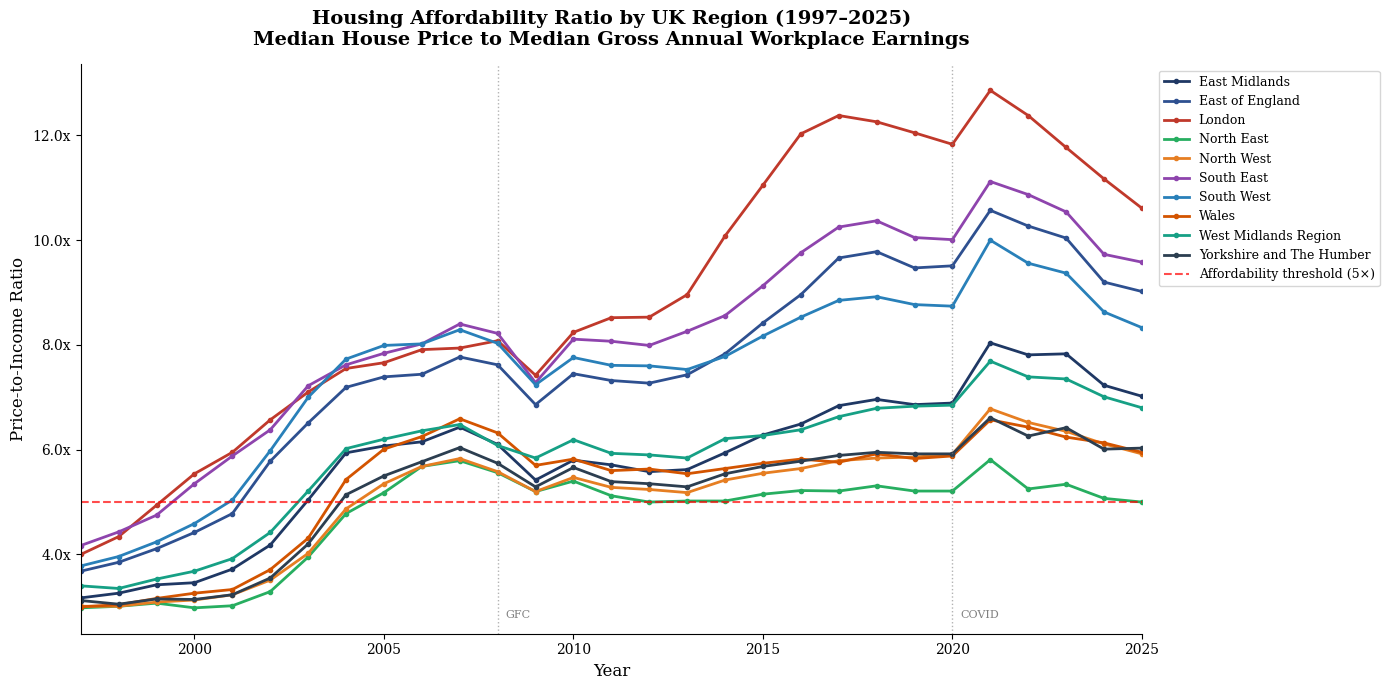

✓ Plot 1 saved


In [23]:
# ============================================================
# CELL 19 — Plot 1: Affordability ratio trends by region
#
# Research Question 1: How has housing affordability evolved
# across UK regions over time?
#
# This is your headline visualisation — it tells the entire
# story of UK regional affordability in one chart.
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))

for i, region in enumerate(sorted(master['region'].unique())):
    data = master[master['region'] == region].sort_values('year')
    ax.plot(
        data['year'],
        data['affordability_ratio'],
        label=region,
        color=PALETTE[i],
        linewidth=2,
        marker='o',
        markersize=3
    )

# ONS policy affordability threshold — homes costing more
# than 5x earnings are classified as unaffordable by ONS
ax.axhline(
    y=5, color='red', linestyle='--',
    linewidth=1.5, alpha=0.7,
    label='Affordability threshold (5×)'
)

# Mark key events
ax.axvline(x=2008, color='grey', linestyle=':', linewidth=1, alpha=0.6)
ax.axvline(x=2020, color='grey', linestyle=':', linewidth=1, alpha=0.6)
ax.text(2008.2, ax.get_ylim()[0] + 0.3, 'GFC', fontsize=8, color='grey')
ax.text(2020.2, ax.get_ylim()[0] + 0.3, 'COVID', fontsize=8, color='grey')

ax.set_title(
    'Housing Affordability Ratio by UK Region (1997–2025)\n'
    'Median House Price to Median Gross Annual Workplace Earnings',
    fontweight='bold'
)
ax.set_xlabel('Year')
ax.set_ylabel('Price-to-Income Ratio')
ax.set_xlim(1997, 2025)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1fx'))
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(PROCESSED + 'plot1_affordability_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot 1 saved")

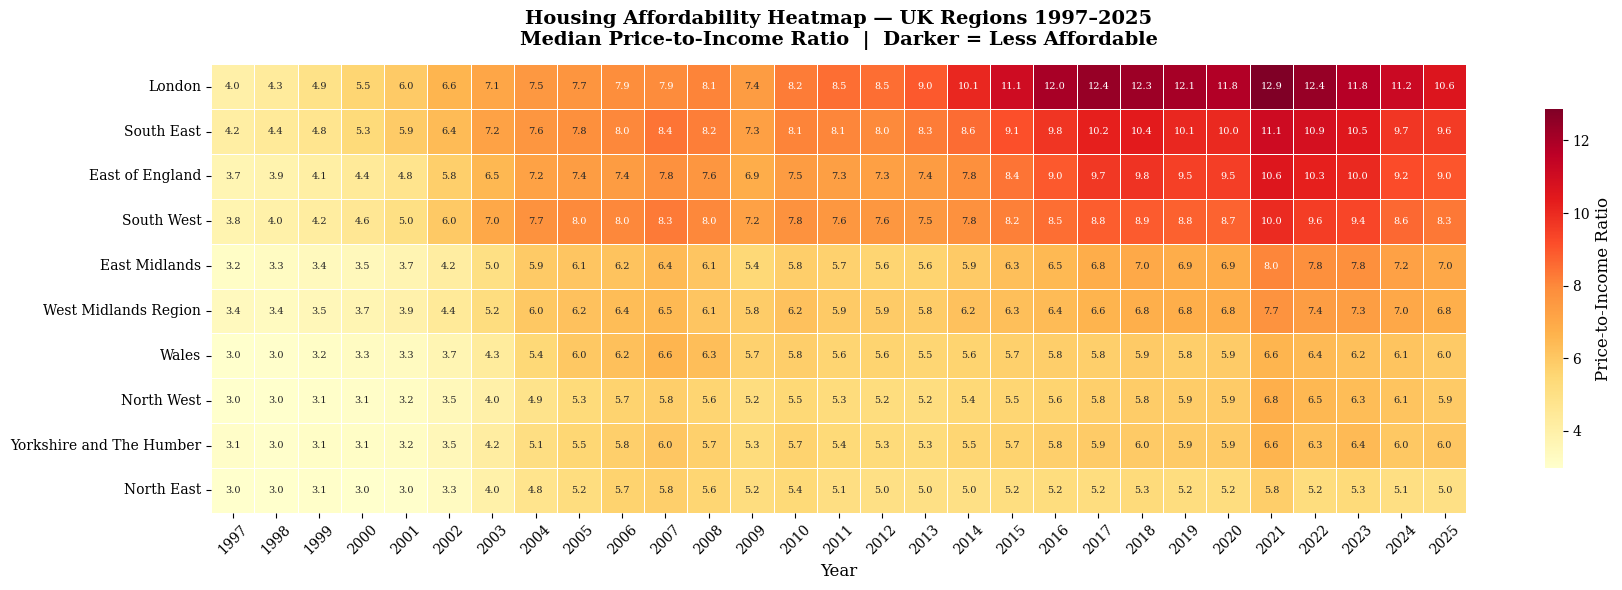

✓ Plot 2 saved


In [24]:
# ============================================================
# CELL 20 — Plot 2: Affordability heatmap
#
# The single most powerful visualisation for your dissertation.
# Shows all regions and all years simultaneously.
# Dark red = severely unaffordable, yellow = more affordable.
# Examiners will reference this in your viva.
# ============================================================

heatmap_data = master.pivot(
    index='region',
    columns='year',
    values='affordability_ratio'
)

# Sort regions by their 2024 ratio — most unaffordable at top
sort_order = (heatmap_data
              .loc[:, 2024]
              .sort_values(ascending=False)
              .index)
heatmap_data = heatmap_data.loc[sort_order]

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    annot=True,
    fmt='.1f',
    linewidths=0.4,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Price-to-Income Ratio', 'shrink': 0.8},
    annot_kws={'size': 7}
)

ax.set_title(
    'Housing Affordability Heatmap — UK Regions 1997–2025\n'
    'Median Price-to-Income Ratio  |  Darker = Less Affordable',
    fontweight='bold'
)
ax.set_xlabel('Year')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(PROCESSED + 'plot2_affordability_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot 2 saved")

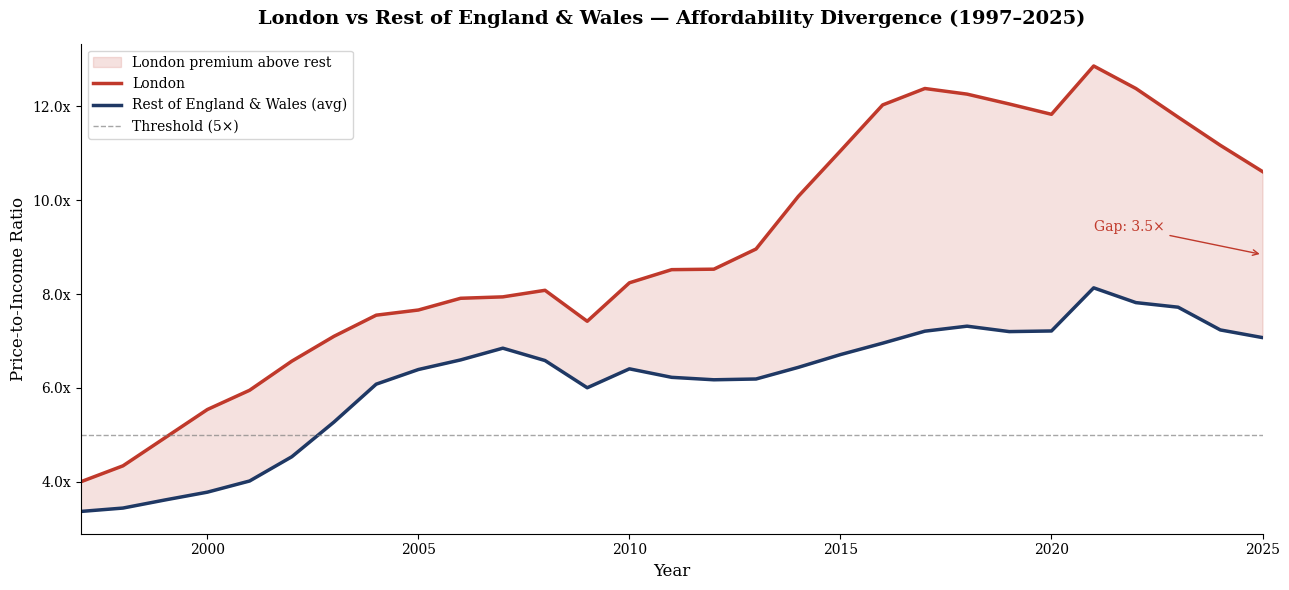

✓ Plot 3 saved


In [25]:
# ============================================================
# CELL 21 — Plot 3: London vs rest of England and Wales
#
# Quantifies the regional inequality argument that justifies
# your project. The widening gap is your key finding from EDA.
# ============================================================

london = master[master['region'] == 'London'].sort_values('year')
rest   = (master[master['region'] != 'London']
          .groupby('year')['affordability_ratio']
          .mean()
          .reset_index())

fig, ax = plt.subplots(figsize=(13, 6))

ax.fill_between(
    london['year'],
    london['affordability_ratio'],
    rest['affordability_ratio'],
    alpha=0.15, color='#C0392B',
    label='London premium above rest'
)
ax.plot(
    london['year'], london['affordability_ratio'],
    color='#C0392B', linewidth=2.5, label='London'
)
ax.plot(
    rest['year'], rest['affordability_ratio'],
    color='#1F3864', linewidth=2.5,
    label='Rest of England & Wales (avg)'
)
ax.axhline(y=5, color='grey', linestyle='--',
           linewidth=1, alpha=0.7, label='Threshold (5×)')

# Annotate the gap in latest year
latest_year = london['year'].max()
london_val  = london.loc[london['year']==latest_year, 'affordability_ratio'].values[0]
rest_val    = rest.loc[rest['year']==latest_year, 'affordability_ratio'].values[0]
gap         = london_val - rest_val
ax.annotate(
    f'Gap: {gap:.1f}×',
    xy=(latest_year, (london_val + rest_val) / 2),
    xytext=(latest_year - 4, (london_val + rest_val) / 2 + 0.5),
    fontsize=10, color='#C0392B',
    arrowprops=dict(arrowstyle='->', color='#C0392B')
)

ax.set_title(
    'London vs Rest of England & Wales — Affordability Divergence (1997–2025)',
    fontweight='bold'
)
ax.set_xlabel('Year')
ax.set_ylabel('Price-to-Income Ratio')
ax.set_xlim(1997, 2025)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1fx'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(PROCESSED + 'plot3_london_divergence.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot 3 saved")

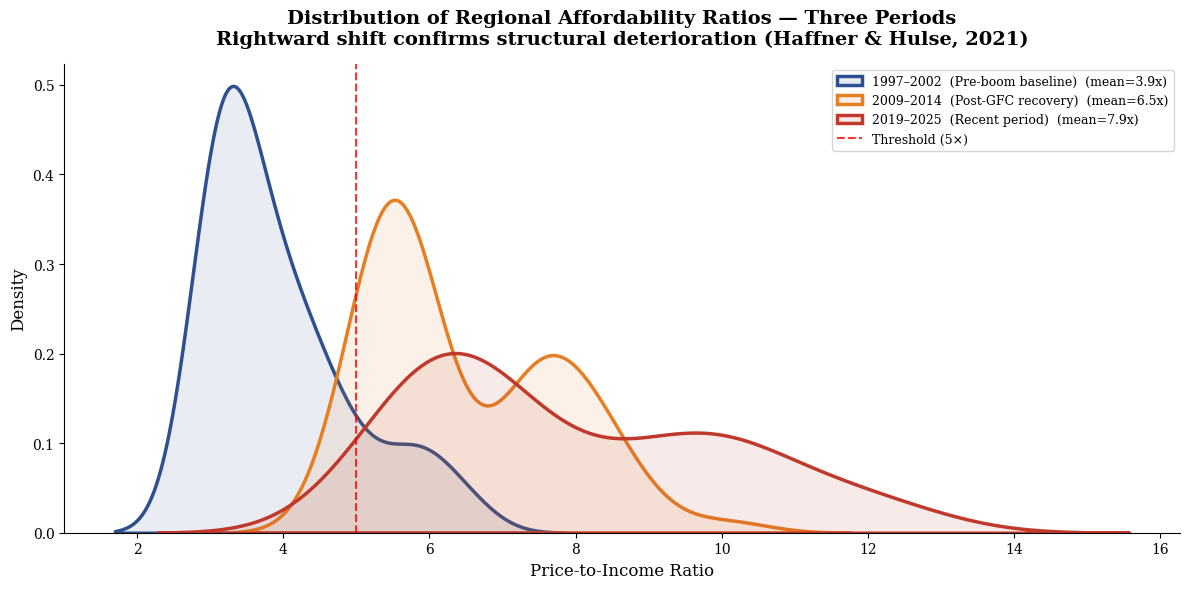

✓ Plot 4 saved


In [26]:
# ============================================================
# CELL 22 — Plot 4: Distribution of ratios across three periods
#
# Shows the structural rightward shift in affordability ratios
# — the distribution is not just moving but widening.
# This is your strongest evidence that the problem is
# structural not cyclical (Haffner & Hulse, 2021).
# ============================================================

periods = {
    '1997–2002  (Pre-boom baseline)': (1997, 2002),
    '2009–2014  (Post-GFC recovery)': (2009, 2014),
    '2019–2025  (Recent period)':     (2019, 2025)
}
period_colors = ['#2E5090', '#E67E22', '#C0392B']

fig, ax = plt.subplots(figsize=(12, 6))

for (label, (y_start, y_end)), color in zip(periods.items(), period_colors):
    subset = master[
        (master['year'] >= y_start) &
        (master['year'] <= y_end)
    ]['affordability_ratio'].dropna()
    sns.kdeplot(
        subset, ax=ax, label=f"{label}  (mean={subset.mean():.1f}x)",
        color=color, linewidth=2.5, fill=True, alpha=0.1
    )

ax.axvline(x=5, color='red', linestyle='--',
           linewidth=1.5, alpha=0.8, label='Threshold (5×)')
ax.set_title(
    'Distribution of Regional Affordability Ratios — Three Periods\n'
    'Rightward shift confirms structural deterioration (Haffner & Hulse, 2021)',
    fontweight='bold'
)
ax.set_xlabel('Price-to-Income Ratio')
ax.set_ylabel('Density')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(PROCESSED + 'plot4_distribution_shift.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot 4 saved")

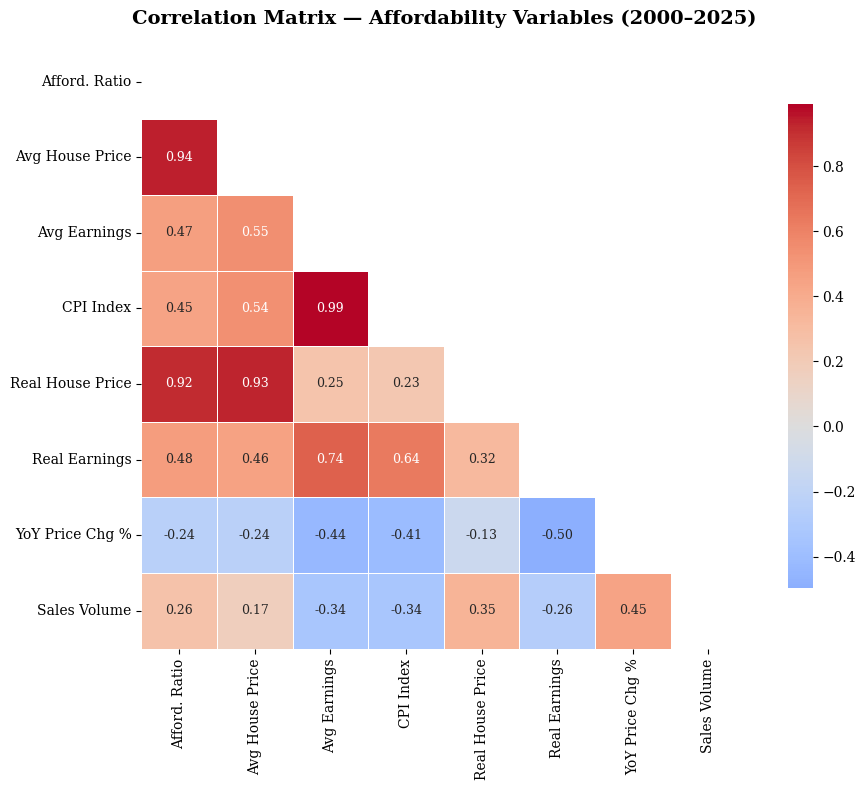

✓ Plot 5 saved


In [27]:
# ============================================================
# CELL 23 — Plot 5: Correlation matrix
#
# Research Question 2: Which socio-economic factors most
# strongly influence affordability?
# This is your first quantitative answer — use 2000+ data
# only where all variables are present.
# ============================================================

corr_vars = [
    'affordability_ratio',
    'avg_price_annual',
    'avg_annual_earnings',
    'cpi_index',
    'real_house_price',
    'real_annual_earnings',
    'yoy_price_change_pct',
    'sales_volume_annual'
]

corr_data   = master[master['year'] >= 2000][corr_vars].dropna()
corr_matrix = corr_data.corr()

# Rename for cleaner labels
label_map = {
    'affordability_ratio':   'Afford. Ratio',
    'avg_price_annual':      'Avg House Price',
    'avg_annual_earnings':   'Avg Earnings',
    'cpi_index':             'CPI Index',
    'real_house_price':      'Real House Price',
    'real_annual_earnings':  'Real Earnings',
    'yoy_price_change_pct':  'YoY Price Chg %',
    'sales_volume_annual':   'Sales Volume'
}
corr_matrix = corr_matrix.rename(index=label_map, columns=label_map)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    mask=mask,
    ax=ax,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 9}
)
ax.set_title(
    'Correlation Matrix — Affordability Variables (2000–2025)',
    fontweight='bold'
)
plt.tight_layout()
plt.savefig(PROCESSED + 'plot5_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot 5 saved")

In [28]:
# ============================================================
# CELL 24 — Regional summary statistics
#
# This becomes Table 4.1 in your dissertation.
# Report these exact figures in your results chapter.
# ============================================================

summary = (master
           .groupby('region')
           .agg(
               ratio_1997  = ('affordability_ratio',
                               lambda x: x[master.loc[x.index,'year']==1997].mean()),
               ratio_2024  = ('affordability_ratio',
                               lambda x: x[master.loc[x.index,'year']==2024].mean()),
               ratio_mean  = ('affordability_ratio', 'mean'),
               ratio_max   = ('affordability_ratio', 'max'),
               ratio_max_yr= ('year',
                               lambda x: master.loc[
                                   x.index[master.loc[x.index,'affordability_ratio']
                                           ==master.loc[x.index,'affordability_ratio'].max()]
                               ,'year'].values[0] if len(x) > 0 else None),
               price_2024  = ('avg_price_annual',
                               lambda x: x[master.loc[x.index,'year']==2024].mean()),
           )
           .round(2)
           .sort_values('ratio_2024', ascending=False))

print("── Regional Affordability Summary (1997–2025):")
print(summary.to_string())
summary.to_csv(PROCESSED + 'summary_statistics.csv')
print("\n✓ summary_statistics.csv saved")

── Regional Affordability Summary (1997–2025):
                          ratio_1997  ratio_2024  ratio_mean  ratio_max  ratio_max_yr  price_2024
region                                                                                           
London                          4.00       11.17        8.96      12.86          2021   556103.58
South East                      4.17        9.73        8.21      11.12          2021   374675.25
East of England                 3.68        9.20        7.57      10.57          2021   329196.25
South West                      3.78        8.63        7.52      10.00          2021   300062.08
East Midlands                   3.17        7.23        5.84       8.04          2021   231829.17
West Midlands Region            3.40        7.01        5.88       7.69          2021   237893.42
Wales                           3.00        6.13        5.33       6.59          2007   203050.67
North West                      3.01        6.11        5.12       6.78

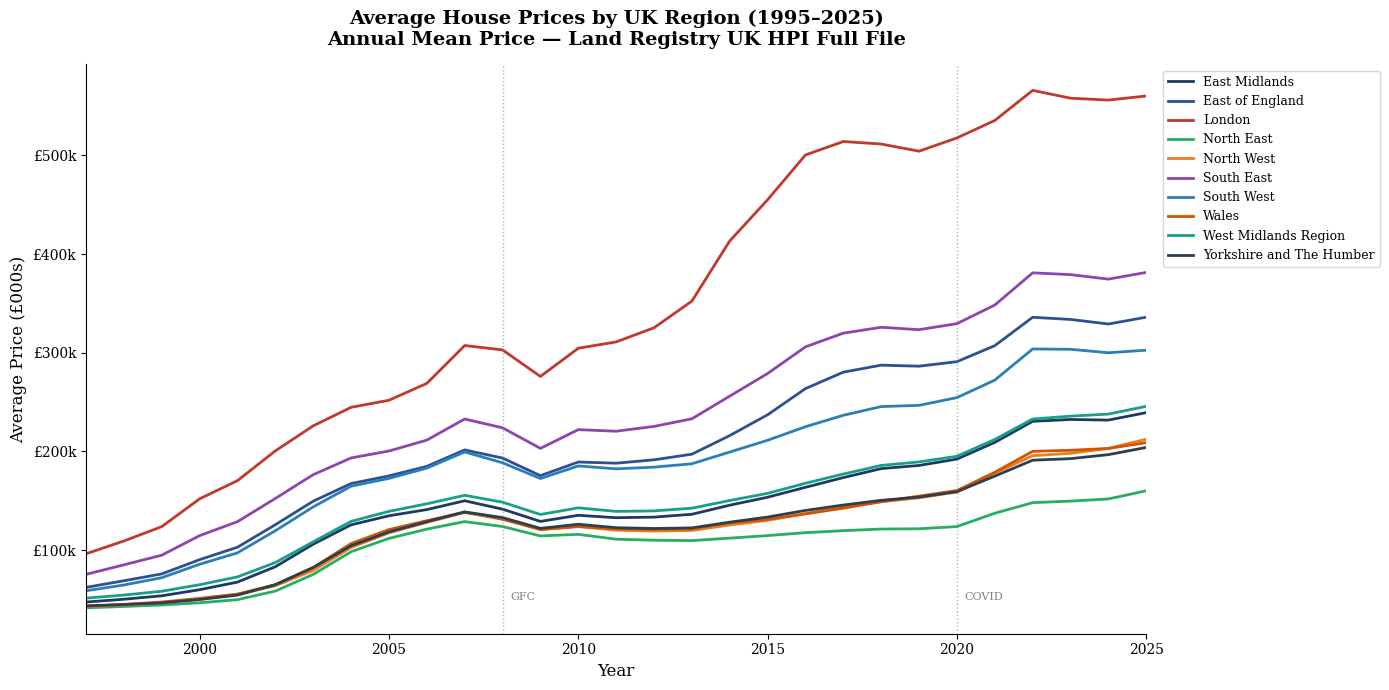

✓ Plot 6 saved


In [35]:
# ============================================================
# CELL 25 — Plot 6: Average house prices by region in £
#
# Shows absolute price divergence in monetary terms.
# Complements Plot 1 (ratio) by showing the raw price gap.
# Important for dissertation — ratio alone does not show
# how far out of reach prices are in absolute terms.
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))

for i, region in enumerate(sorted(master['region'].unique())):
    data = master[master['region'] == region].sort_values('year')
    ax.plot(
        data['year'],
        data['avg_price_annual'] / 1000,
        label=region,
        color=PALETTE[i],
        linewidth=2
    )

# Mark key events
ax.axvline(x=2008, color='grey', linestyle=':', linewidth=1, alpha=0.6)
ax.axvline(x=2020, color='grey', linestyle=':', linewidth=1, alpha=0.6)
ax.text(2008.2, 50, 'GFC',   fontsize=8, color='grey')
ax.text(2020.2, 50, 'COVID', fontsize=8, color='grey')

ax.set_title(
    'Average House Prices by UK Region (1995–2025)\n'
    'Annual Mean Price — Land Registry UK HPI Full File',
    fontweight='bold'
)
ax.set_xlabel('Year')
ax.set_ylabel('Average Price (£000s)')
ax.set_xlim(1997, 2025)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:.0f}k')
)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(PROCESSED + 'plot6_house_prices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot 6 saved")

In [37]:
# ============================================================
# CELL 26 — Augmented Dickey-Fuller stationarity tests
#
# WHY THIS MATTERS FOR YOUR PROJECT:
# ARIMA requires stationary time series. Most economic time
# series — including house prices and affordability ratios —
# are non-stationary in levels (they trend upward over time).
# We must confirm this empirically before modelling.
#
# The ADF test:
#   H0: series has a unit root (non-stationary)
#   H1: series is stationary
#   If p > 0.05: fail to reject H0 → non-stationary
#   If p < 0.05: reject H0 → stationary
#
# We test the affordability ratio for each region.
# We expect non-stationarity in levels but stationarity
# after first differencing — this is the I(1) property
# that ARIMA(p,1,q) models are designed to handle.
#
# Reference: Box and Jenkins (1976) — your methodology citation
# ============================================================

from statsmodels.tsa.stattools import adfuller

results = []

for region in sorted(master['region'].unique()):
    series = (master[master['region'] == region]
              .sort_values('year')['affordability_ratio']
              .dropna()
              .values)

    # ── Test levels (original series) ────────────────────────
    adf_level = adfuller(series, autolag='AIC')

    # ── Test first differences ────────────────────────────────
    series_diff = pd.Series(series).diff().dropna().values
    adf_diff    = adfuller(series_diff, autolag='AIC')

    results.append({
        'region':          region,
        'adf_stat_level':  round(adf_level[0], 3),
        'p_value_level':   round(adf_level[1], 4),
        'stationary_lvl':  'No' if adf_level[1] > 0.05 else 'Yes',
        'adf_stat_diff':   round(adf_diff[0], 3),
        'p_value_diff':    round(adf_diff[1], 4),
        'stationary_diff': 'No' if adf_diff[1] > 0.05 else 'Yes',
        'integration':     'I(1)' if (adf_level[1] > 0.05 and
                                       adf_diff[1] <= 0.05) else
                           'I(0)' if adf_level[1] <= 0.05 else
                           'I(2)+'
    })

adf_results = pd.DataFrame(results)

print("=" * 70)
print("AUGMENTED DICKEY-FULLER TEST RESULTS — Affordability Ratio")
print("=" * 70)
print(f"\nNull hypothesis: series has a unit root (non-stationary)")
print(f"Significance level: 5% (p > 0.05 = non-stationary)\n")
print(adf_results.to_string(index=False))
print(f"\n── Summary:")
print(f"   Non-stationary in levels : "
      f"{(adf_results['stationary_lvl']=='No').sum()}/10 regions")
print(f"   Stationary after diff    : "
      f"{(adf_results['stationary_diff']=='Yes').sum()}/10 regions")
print(f"   Integration order I(1)   : "
      f"{(adf_results['integration']=='I(1)').sum()}/10 regions")

AUGMENTED DICKEY-FULLER TEST RESULTS — Affordability Ratio

Null hypothesis: series has a unit root (non-stationary)
Significance level: 5% (p > 0.05 = non-stationary)

                  region  adf_stat_level  p_value_level stationary_lvl  adf_stat_diff  p_value_diff stationary_diff integration
           East Midlands          -1.818         0.3717             No         -3.948        0.0017             Yes        I(1)
         East of England          -2.127         0.2339             No         -3.954        0.0017             Yes        I(1)
                  London          -1.936         0.3155             No         -3.732        0.0037             Yes        I(1)
              North East          -3.224         0.0186            Yes         -3.727        0.0038             Yes        I(0)
              North West          -1.847         0.3574             No         -3.478        0.0086             Yes        I(1)
              South East          -2.345         0.1579        

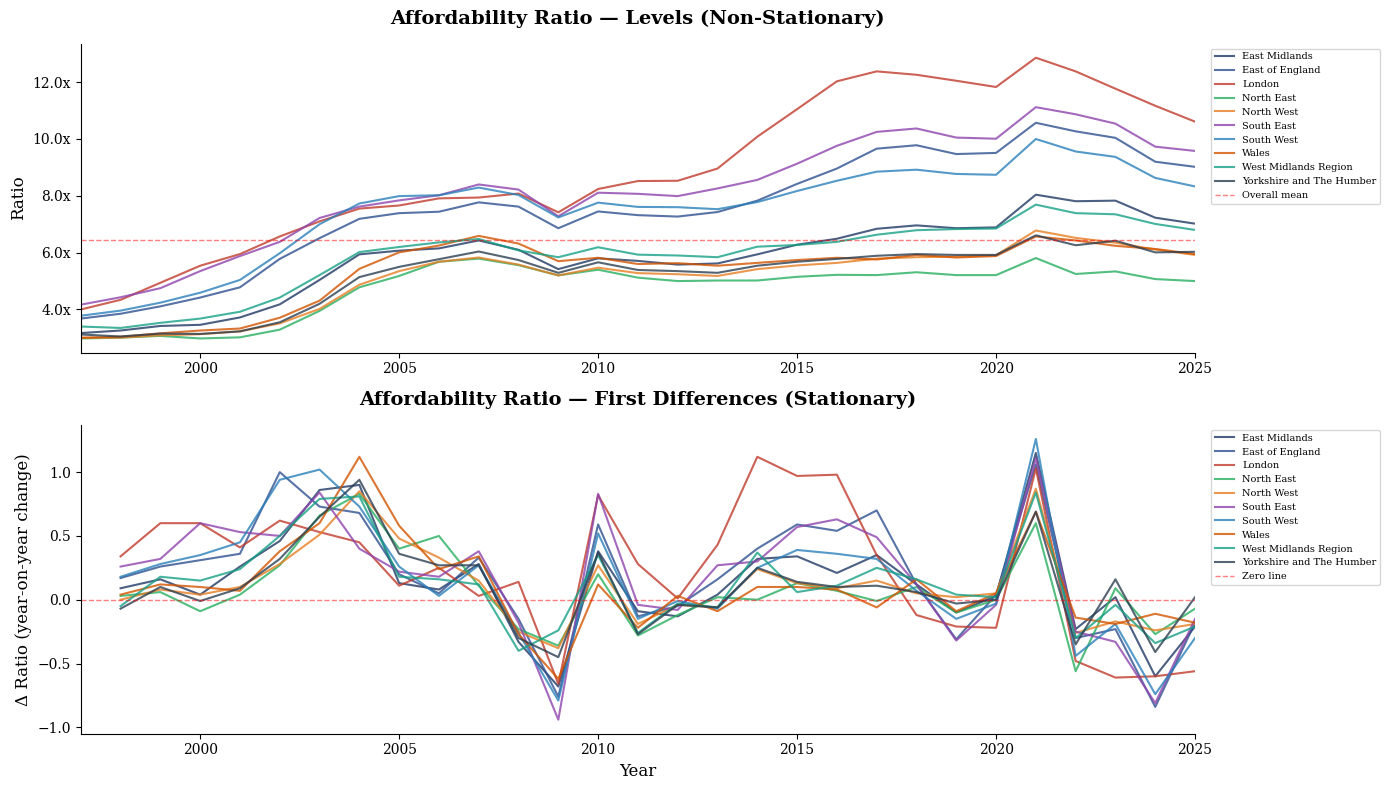

✓ Plot 7 saved


In [38]:
# ============================================================
# CELL 27 — Visualise levels vs first differences
#
# Shows visually why differencing is needed before ARIMA.
# This figure goes in your methodology chapter to justify
# the d=1 parameter in your ARIMA(p,1,q) specification.
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# ── Panel 1: Levels — should show clear trend (non-stationary)
for i, region in enumerate(sorted(master['region'].unique())):
    data = master[master['region'] == region].sort_values('year')
    axes[0].plot(
        data['year'],
        data['affordability_ratio'],
        color=PALETTE[i], linewidth=1.5, alpha=0.8,
        label=region
    )

axes[0].set_title(
    'Affordability Ratio — Levels (Non-Stationary)',
    fontweight='bold'
)
axes[0].set_ylabel('Ratio')
axes[0].set_xlim(1997, 2025)
axes[0].axhline(
    y=master['affordability_ratio'].mean(),
    color='red', linestyle='--', linewidth=1,
    alpha=0.5, label='Overall mean'
)
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1fx'))

# ── Panel 2: First differences — should be stationary
master_sorted = master.sort_values(['region', 'year'])
master_sorted['ratio_diff'] = master_sorted.groupby(
    'region')['affordability_ratio'].diff()

for i, region in enumerate(sorted(master_sorted['region'].unique())):
    data = master_sorted[master_sorted['region'] == region].dropna(
        subset=['ratio_diff'])
    axes[1].plot(
        data['year'],
        data['ratio_diff'],
        color=PALETTE[i], linewidth=1.5, alpha=0.8,
        label=region
    )

axes[1].set_title(
    'Affordability Ratio — First Differences (Stationary)',
    fontweight='bold'
)
axes[1].set_ylabel('Δ Ratio (year-on-year change)')
axes[1].set_xlabel('Year')
axes[1].set_xlim(1997, 2025)
axes[1].axhline(y=0, color='red', linestyle='--',
                linewidth=1, alpha=0.5, label='Zero line')
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)

plt.tight_layout()
plt.savefig(PROCESSED + 'plot7_stationarity.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot 7 saved")

In [39]:
# ── Save ADF results ──────────────────────────────────────────
adf_results.to_csv(PROCESSED + 'adf_test_results.csv', index=False)
print("✓ adf_test_results.csv saved")

✓ adf_test_results.csv saved


In [40]:
# ============================================================
# CELL 29 — Document stationarity decision for dissertation
#
# This cell produces the methodological note you will cite
# in Chapter 4 when justifying ARIMA(p,1,q) specification.
# ============================================================

print("=" * 65)
print("STATIONARITY DECISION — Methodological Note")
print("=" * 65)

print("""
ADF Test Summary:
  8/10 regions: I(1) confirmed — non-stationary in levels,
                stationary after first differencing
  2/10 regions: Borderline I(0) — North East (p=0.019),
                Wales (p=0.030)

Methodological position adopted:
  All 10 series treated as I(1) for the following reasons:

  1. Low test power: ADF has limited power with n=29 annual
     observations. Small samples increase Type II error risk
     (failing to detect a unit root that exists).

  2. Visual evidence: Panel 1 of Plot 7 shows clear upward
     trends in both North East and Wales with no mean
     reversion — consistent with I(1) behaviour.

  3. Economic theory: Housing affordability ratios are driven
     by house prices which are well-established I(1) processes
     in the UK housing economics literature (Meen, 2002).

  4. Consistency: Applying d=1 uniformly across all regions
     ensures a comparable, reproducible modelling framework.

Decision: ARIMA(p,1,q) / SARIMA(p,1,q)(P,1,Q)s applied
to all 10 regional series in notebook 04_forecasting.ipynb.

Cite: Box and Jenkins (1976), Meen (2002)
""")

# Save decision record
with open(PROCESSED + 'stationarity_decision.txt', 'w') as f:
    f.write("North East p=0.019, Wales p=0.030 — borderline I(0)\n")
    f.write("Decision: treat all 10 as I(1) — visual + theory\n")
    f.write("ARIMA d=1 applied uniformly across all regions\n")

print("✓ Stationarity decision documented")

STATIONARITY DECISION — Methodological Note

ADF Test Summary:
  8/10 regions: I(1) confirmed — non-stationary in levels,
                stationary after first differencing
  2/10 regions: Borderline I(0) — North East (p=0.019),
                Wales (p=0.030)

Methodological position adopted:
  All 10 series treated as I(1) for the following reasons:

  1. Low test power: ADF has limited power with n=29 annual
     observations. Small samples increase Type II error risk
     (failing to detect a unit root that exists).

  2. Visual evidence: Panel 1 of Plot 7 shows clear upward
     trends in both North East and Wales with no mean
     reversion — consistent with I(1) behaviour.

  3. Economic theory: Housing affordability ratios are driven
     by house prices which are well-established I(1) processes
     in the UK housing economics literature (Meen, 2002).

  4. Consistency: Applying d=1 uniformly across all regions
     ensures a comparable, reproducible modelling framework.

Dec